# Binary Classification (Logistic Regression) 

## Overview
Binary classification is one of the most fundamental and common tasks in machine learning and deep learning. 
At its core, it's a supervised learning problem where the goal is to categorize input data into one of two possible classes or categories. 
Think of it as teaching a machine to make a "yes" or "no" decision.
Examples of binary classification's applications are:

- Spam Detection: Classifying an email as either 'spam' or 'not spam'.
- Medical Diagnosis: Determining if a patient has a certain disease.
- Credit Scoring: Deciding whether a loan applicant is a 'good credit risk' or a 'bad credit risk'.
- Collision Detection: Differentiate deliberate environmental interaction forces from unintended physical impacts.

A sigmoid activated multi-input, single-output linear model is a decent candidate for this job.
In this practice, you'll train such a model to categorize samples from a toy dataset into two classes.

## Problem Definition
Using synthetic data generated by [`make_blobs`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html#sklearn.datasets.make_blobs), Construct a model to categorize points in 2D space into two clusters.

## Objectives
- Train a simple neural network model.
    - Apply sigmoid activation on a linear model.
    - Implement binary cross entropy evaluation.
    - Practice vectorized computing.
- Assess model's performance using a variety of metrics.


## Exercises:
<font color=#582C83>

1. (5%) Data Pre-Processing
2. (10%) Model Creation
3. (20%) Model Assessment
4. (10%) Gradient of BCE Loss
5. (30%) Gradient Descent Model Optimization
6. (25%) Classification Metrics

</font>


## 1. Load and Pre-Process Training Dataset

The dataset, 
$$\mathcal{D} = \{\mathbf{X}, \mathbf{y}\} = \begin{bmatrix} ^{(1)} \mathbf{x} & ^{(1)} y \\ ^{(2)} \mathbf{x} & ^{(2)} y \\ \vdots \\ ^{(M)} \mathbf{x} & ^{(M)} y \end{bmatrix}$$
consists $M$ samples.

Each sample has $N$ features: $^{(i)} \mathbf{x} = [^{(i)} x_1, ^{(i)} x_2, \dots, ^{(i)} x_N]$ and is labeled as $^{(i)} y \in \{0, 1\}$, where $i \in \{1, 2, ..., M\}$.

In this practice, we make a toy dataset using [scikit-learn](https://scikit-learn.org/stable/index.html)'s [datasets](https://scikit-learn.org/stable/api/sklearn.datasets.html) module. 
The dataset has $M=2048$ samples, and $N=2$ features. 

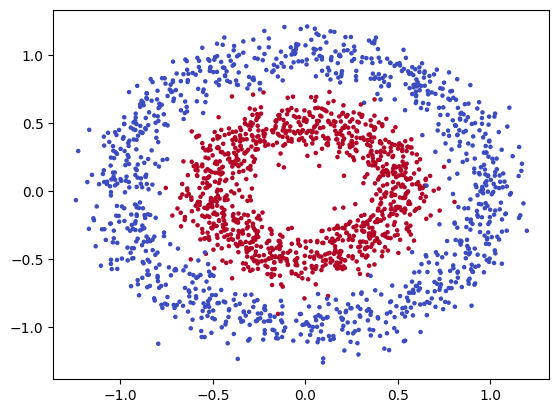

In [1]:
from sklearn.datasets import make_blobs, make_circles
import numpy as np
import matplotlib.pyplot as plt
rng_seed = 3321

# features_raw, labels_raw = make_blobs(n_samples=2048, centers=np.array([[4, 4], [2, 1]]), cluster_std=1.0, random_state=3321)
features_raw, labels_raw = make_circles(n_samples=2048, shuffle=True, noise=0.1, random_state=rng_seed, factor=0.5)
# Visualize the raw data
plt.scatter(
    features_raw[:, 0], # feature 1 values (x coords)
    features_raw[:, 1], # feature 2 values (y coords)
    s=5*np.ones(labels_raw.size), # marker size all set to 1
    c=labels_raw, # colorized labels: 0:blue, 1:red
    cmap='coolwarm'  # color map
)


### <font color=#582C83>(5%) Exercise 1: Data Pre-Processing</font>
1. Let's implement a maximum scaling to the features.
2. To follow the convention in Linear Algebra, reshape labels array into a 2-dimension array as a column vector.

Samples of max-scaled features:
 [[ 0.33894904 -0.08088946]
 [-0.67719531 -0.38727521]
 [-0.53396025  0.48407507]
 [-0.14622006 -0.35573736]]
Shape of max-scaled features:
 (2048, 2).
Samples of reshaped labels:
 [[1]
 [0]
 [0]
 [1]]
Shape of reshaped labels:
 (2048, 1)


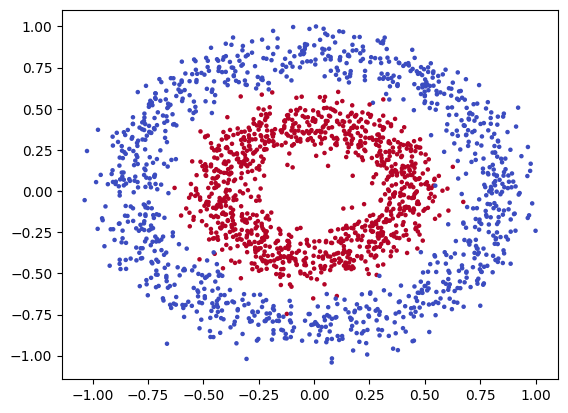

In [2]:
### START CODING HERE ### (≈ 2 lines of code)
features_train = features_raw / features_raw.max(axis=0)  # Scale features to interval: [0, 1]
labels_train = labels_raw.reshape(-1, 1)  # Reshape labels to be a column vector
### END CODING HERE ### 

# Sanity check
print(f"Samples of max-scaled features:\n {features_train[-4:]}")
print(f"Shape of max-scaled features:\n {features_train.shape}.")
print(f"Samples of reshaped labels:\n {labels_train[-4:]}")  # Print last 4 samples of features and labels
print(f"Shape of reshaped labels:\n {labels_train.shape}")  # Print shapes of features and labels   

# Visualize
plt.scatter(
    features_train[:, 0], 
    features_train[:, 1], 
    s=5*np.ones(labels_train.size), 
    c=labels_train, 
    cmap='coolwarm'  # color map
)

**Expected Outcomes**:
```console
Samples of max-scaled features:
 [[0.70512976 0.40272977]
 [0.48440596 0.03606424]
 [0.65701253 0.43314779]
 [0.37337176 0.14536872]]
Shape of max-scaled features:
 (2048, 2).
Samples of reshaped labels:
 [[0]
 [1]
 [0]
 [1]]
Shape of reshaped labels:
 (2048, 1)
``` 

## 2. Create a Non-linear Multi-Input Single-Output Model
Let's create a nonlinear model by applying a sigmoid function to the output of a linear model.

$$\mathbf{\hat{y}} = \sigma (\mathbf{X} \cdot \mathbf{w}^T + \mathbf{b}) = \sigma(\mathbf{Z})$$

The sigmoid function can be represented as,

$$\sigma(\mathbf{Z}) = \frac{1}{1 + e^{-\mathbf{Z}}}$$

The linear part of the model is governed by a parameter vector 
$$\mathbf{w} = [w_1, w_2, ..., w_N]_{(1, N)}$$

and a bias vector 
$$\mathbf{b} = \begin{bmatrix} b \\ b \\ \vdots \\ b \end{bmatrix}_{(M, 1)}$$

And, in this practice $M=2048$ and $N=2$

### <font color=#582C83>(10%) Exercise 2: Model Creation</font>
Let's translate math to code. 

Samples of dummy prediction:
 [[0.35269466]
 [0.24565877]
 [0.04954192]
 [0.36417979]]


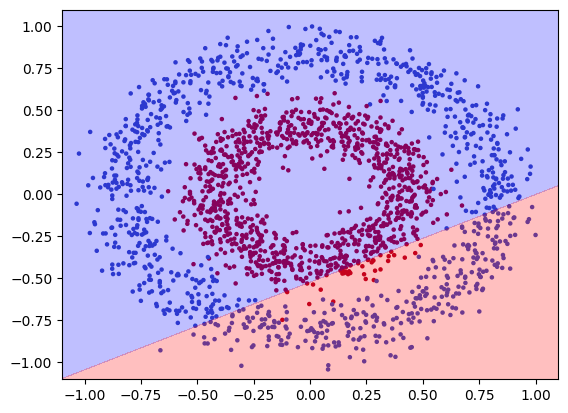

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def linear(in_features, weights, bias):
    out_features = in_features @ weights.T + bias
    return out_features

def model_n01(in_features, weights, bias):
    """
    Compute the linear combination of inputs and weights plus bias.
    
    Args:
        in_features (np.ndarray): Input features of shape (M, N).
        weights (np.ndarray): Weights of shape (1, N).
        bias (float): Bias term.  
    Returns:
        predictions: Linear combination result of shape (M, 1).
    """
    ### START CODING HERE ### (≈ 2 lines of code)
    predictions = sigmoid(linear(in_features, weights, bias))
    return predictions
    ### END CODING HERE ###

# Sanity check
w_dummy = np.array([[1.2, -2.3]])
b_dummy = -1.2
print(f"Samples of dummy prediction:\n {model_n01(features_train, w_dummy, b_dummy)[-4:]}")  # Print last 4 samples of dummy prediction

# Visualize dummy model decision boundary
plt.scatter(features_train[:, 0], features_train[:, 1], s=5*np.ones(labels_train.size), c=labels_train, cmap='coolwarm')
# Create a meshgrid of points over the feature space
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 300),
                     np.linspace(-1.1, 1.1, 300))
zz = sigmoid(w_dummy[0, 0] * xx + w_dummy[0, 1] * yy + b_dummy) - 0.5
plt.contourf(xx, yy, zz, levels=[-np.inf, 0, np.inf], colors=['blue', 'red'], alpha=0.25)


**Expected Outcomes**:
>
```console
Samples of dummy prediction:
 [[0.71501709]
 [0.81732667]
 [0.68829818]
 [0.7528179 ]]
```

## 3. Evaluate Model
As same as the linear regression, we need to evaluate model performance. 
It is OK to use a Mean Squared Error (MSE) function, but a Binary Cross Entropy (BCE) function (below) is more suitable for such a problem. 

$$\mathcal{L}(\mathbf{\hat{y}}, \mathbf{y}) = \frac{1}{M} \Sigma [-\mathbf{y} \log \hat{\mathbf{y}} - (1 - \mathbf{y}) \log(1 - \hat{\mathbf{y}})]$$

Another metric for classification problems in general is the accuracy.
Let $TP$ be number of true positive predictions, $TN$ be number of true negative predictions, $FP$ be number of false positive predictions, $FN$ be number of false negative predictions.
The accuracy is defined as:
$$Accuracy = \frac{TP + TN}{TP+FP+TN+FN}$$

### <font color=#582C83>(20%) Exercise 3: Model Assessment</font>
1. Evaluate model loss with BCE function.
2. Assess model predictions accuracy.

In [4]:
def bce_loss(predictions, labels):
    """
    Compute the Binary Cross Entropy (BCE) loss.
    
    Args:
        predictions (np.ndarray): Predicted probabilities of shape (M, 1).
        labels (np.ndarray): True binary labels of shape (M, 1).
    Returns:
        loss: BCE loss value (float).
    """
    ### START CODING HERE ### (≈ 1 line)
    loss = np.mean(-labels * np.log(predictions) - (1 - labels) * np.log(1 - predictions))
    return loss
    ### END CODING HERE ###

def accuracy(predictions, labels):
    """
    Compute the accuracy of predictions.
    
    Args:
        predictions (np.ndarray): Predicted probabilities of shape (M, 1).
        labels (np.ndarray): True binary labels of shape (M, 1).
    Returns:
        acc: Accuracy value (float).
    """
    ### START CODING HERE ### (≈ 2 lines)
    predicted_classes = (predictions >= 0.5).astype(int)  # Convert probabilities to binary classes
    acc = np.mean(predicted_classes == labels)
    return acc
    ### END CODING HERE ###

# Sanity check
preds_dummy = model_n01(features_train, w_dummy, b_dummy)
print(f"Dummy model BCE loss: {bce_loss(preds_dummy, labels_train)}")
print(f"Dummy model accuracy: {accuracy(preds_dummy, labels_train) * 100}%")

Dummy model BCE loss: 0.9925228865047314
Dummy model accuracy: 36.328125%


**Expected Output**:
>
```console
Dummy model BCE loss: 0.6591058817210655
Dummy model accuracy: 52.978515625%
```

## 4. Compute Gradient of Loss
Compute gradient of the BCE loss:

$$\frac{\partial \mathcal{L}}{\partial \mathbf{w}} = \begin{bmatrix} \frac{\partial \mathcal{L}}{\partial w_1} & \frac{\partial \mathcal{L}}{\partial w_2} & \dots & \frac{\partial \mathcal{L}}{\partial w_N} \end{bmatrix} = \frac{1}{M} (\hat{\mathbf{y}} - \mathbf{y})^T \cdot \mathbf{X}$$
$$\frac{\partial \mathcal{L}}{\partial b}  = \overline{\hat{\mathbf{y}} - \mathbf{y}} $$

### <font color=#582C83>(10%) Exercise 4: Gradient of BCE Loss</font>

In [5]:
def gradient(predictions, labels, in_features):
    """
    Compute the gradient of the BCE loss with respect to weights and bias.
    
    Args:
        predictions (np.ndarray): Predicted probabilities of shape (M, 1).
        labels (np.ndarray): True binary labels of shape (M, 1).
        in_features (np.ndarray): Input features of shape (M, N).
    Returns:
        dw: Gradient with respect to weights of shape (1, N).
        db: Gradient with respect to bias (float).
    """
    ### START CODING HERE ### (≈ 3 lines of code)
    M = labels.shape[0]  # Number of samples
    dw = 1 / M * np.dot((predictions - labels).T, in_features)  # Gradient w.r.t. weights
    db = np.mean(predictions - labels)  # Gradient w.r.t. bias
    return dw, db
    ### END CODING HERE ###

# Sanity check
dw_dummy, db_dummy = gradient(preds_dummy, labels_train, features_train)
print(f"Dummy model gradient w.r.t. weights: {dw_dummy}, shape: {dw_dummy.shape}")
print(f"Dummy model gradient w.r.t. bias: {db_dummy}")

Dummy model gradient w.r.t. weights: [[ 0.04506402 -0.08373368]], shape: (1, 2)
Dummy model gradient w.r.t. bias: -0.21613454762096518


**Expected Output**:
>
```console
Dummy model gradient w.r.t. weights: [[0.14384675 0.13126987]], shape: (1, 2)
Dummy model gradient w.r.t. bias: 0.18122334811120178
```

## 5. Update Model Parameters


By tweaking the model parameters along the gradient a small step (learning rate, $\alpha$) iteratively, we expect to bring the BCE loss down to a reasonable scale.

- $\text{Initialize } \mathbf{w} \text{ and } b$
- $\text{Repeat until converge}$
    - $\mathbf{w} = \mathbf{w} - \alpha \frac{\partial \mathcal{L}}{\partial \mathbf{w}}$
    - $b = b - \alpha \frac{\partial \mathcal{L}}{\partial b}$

    

### <font color=#582C83>(30%) Exercise 5: Gradient Descent Model Optimization</font>
1. Initialize weights and bias
2. Set learning rate and number of iterations
3. Repeat following steps:

    1. Make predictions
    2. Assess model
    3. Compute gradient of loss
    4. Update weights and bias

<font color=red>**Note: bring training accuracy over 50% within 500 iterations**</font>


Iteration 1/500, Loss: 0.6932, Accuracy: 49.12%
Iteration 2/500, Loss: 0.6932, Accuracy: 49.12%
Iteration 3/500, Loss: 0.6932, Accuracy: 49.27%
Iteration 4/500, Loss: 0.6932, Accuracy: 49.46%
Iteration 5/500, Loss: 0.6932, Accuracy: 49.66%
Iteration 6/500, Loss: 0.6932, Accuracy: 49.56%
Iteration 7/500, Loss: 0.6932, Accuracy: 49.56%
Iteration 8/500, Loss: 0.6932, Accuracy: 49.51%
Iteration 9/500, Loss: 0.6932, Accuracy: 49.46%
Iteration 10/500, Loss: 0.6932, Accuracy: 49.51%
Iteration 11/500, Loss: 0.6932, Accuracy: 49.51%
Iteration 12/500, Loss: 0.6932, Accuracy: 49.56%
Iteration 13/500, Loss: 0.6932, Accuracy: 49.56%
Iteration 14/500, Loss: 0.6932, Accuracy: 49.56%
Iteration 15/500, Loss: 0.6932, Accuracy: 49.76%
Iteration 16/500, Loss: 0.6932, Accuracy: 49.76%
Iteration 17/500, Loss: 0.6932, Accuracy: 49.71%
Iteration 18/500, Loss: 0.6932, Accuracy: 49.85%
Iteration 19/500, Loss: 0.6932, Accuracy: 49.90%
Iteration 20/500, Loss: 0.6932, Accuracy: 49.85%
Iteration 21/500, Loss: 0.693

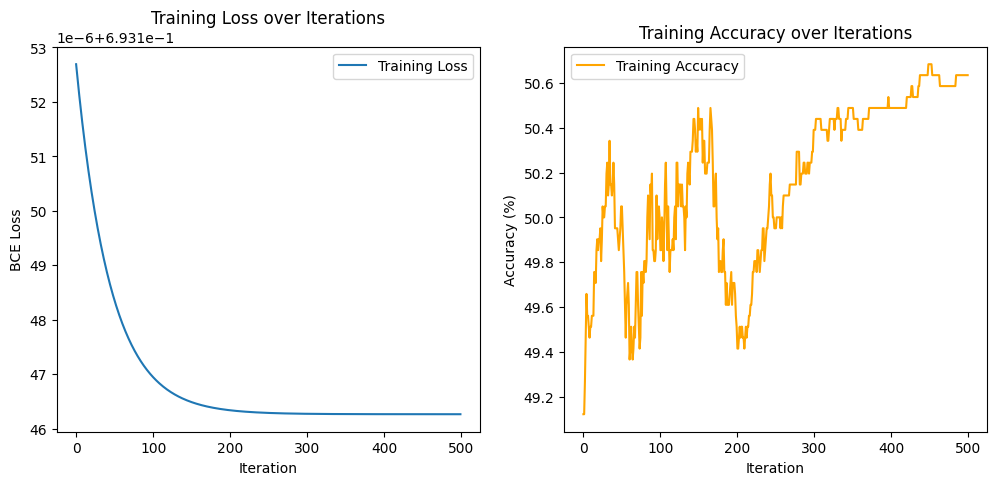

In [6]:
# START CODING HERE ### (≈ 10 lines of code)
# Initialize parameters
w = np.random.normal(loc=0, scale=0.01, size=(1, features_train.shape[1]))  # Initialize weights
b = np.random.normal(loc=0, scale=0.01)  # Initialize bias

# Set hyperparameters
learning_rate = 0.2
num_iters = 500

# Reserve loss and accuracy storage
losses_train = []
accuracies_train = []

# Training loop
for i in range(num_iters):
    preds_train = model_n01(features_train, w, b)  # Make predictions
    loss_train = bce_loss(preds_train, labels_train)  # Assess model loss
    acc_train = accuracy(preds_train, labels_train)  # Assess model accuracy
    print(f"Iteration {i+1}/{num_iters}, Loss: {loss_train:.4f}, Accuracy: {acc_train*100:.2f}%")
    losses_train.append(loss_train)
    accuracies_train.append(acc_train)
    dw, db = gradient(preds_train, labels_train, features_train)  # Compute gradient of loss
    w = w - learning_rate * dw  # Update weights
    b = b - learning_rate * db  # Update bias

### END CODING HERE ###

# Plot training loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_train, label='Training Loss')
plt.xlabel('Iteration')
plt.ylabel('BCE Loss')
plt.title('Training Loss over Iterations')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.array(accuracies_train) * 100, label='Training Accuracy', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy over Iterations')
plt.legend()   

### Visualize Decision Boundary

Text(0.5, 1.0, 'Decision Boundary after Training')

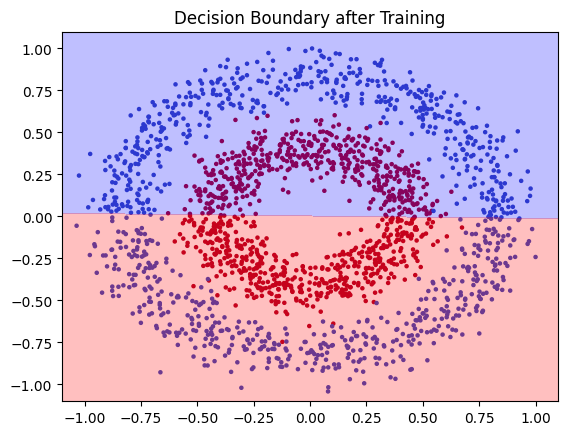

In [7]:
# Visualize decision boundary after training
plt.scatter(features_train[:, 0], features_train[:, 1], s=5*np.ones(labels_train.size), c=labels_train, cmap='coolwarm')
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 300),
                     np.linspace(-1.1, 1.1, 300))
zz = sigmoid(w[0, 0] * xx + w[0, 1] * yy + b) - 0.5
plt.contourf(xx, yy, zz, levels=[-np.inf, 0, np.inf], colors=['blue', 'red'], alpha=0.25)
plt.title('Decision Boundary after Training')

## 5. Upgrade Model
By adding a hidden layer, the original features can be transformed to a higher dimension space. 

Hidden features: 
[[0.75360703 0.23262943 0.78052982 0.32181954]
 [0.61680837 0.37210525 0.81684858 0.39459865]
 [0.61917517 0.42237884 0.82262861 0.46005466]
 ...
 [0.71801148 0.34263332 0.80236882 0.44488994]
 [0.44475449 0.51175795 0.84691656 0.43069558]
 [0.7477204  0.26766211 0.78745462 0.36836619]]
Shape of the hidden features: (2048, 4)
Dummy predictions: 
[[0.12113271]
 [0.13481251]
 [0.1350597 ]
 ...
 [0.12614445]
 [0.15162116]
 [0.12247771]]
Shape of the dummy predictions: (2048, 1)
Dummy predicted class labels: 
[[0]
 [0]
 [0]
 ...
 [0]
 [0]
 [0]]
Dummy model BCE loss: 1.0872126562184723
Dummy model accuracy: 50.0%


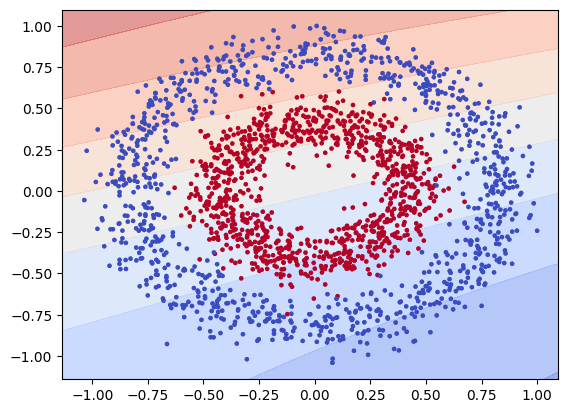

In [8]:
def model_n11(in_features, params):
    hidden_features = sigmoid(linear(in_features, params['W1'], params['b1']))
    predictions = sigmoid(linear(hidden_features, params['W2'], params['b2']))
    return predictions, hidden_features

# Sanity check
np.random.seed(rng_seed)
params_dummy = {
    'W1': np.random.normal(size=(4, features_train.shape[1])),  # dimensions: 2 -> 4
    'b1': np.random.normal(size=(1, 4)),
    'W2': np.random.normal(size=(1, 4)),
    'b2': np.random.normal()
}

preds_dummy, hid_feats_dummy = model_n11(features_train, params_dummy)
print(f"Hidden features: \n{hid_feats_dummy}")
print(f"Shape of the hidden features: {hid_feats_dummy.shape}")
print(f"Dummy predictions: \n{preds_dummy}")
print(f"Shape of the dummy predictions: {preds_dummy.shape}")
print(f"Dummy predicted class labels: \n{(preds_dummy >= 0.5).astype(int)}")
print(f"Dummy model BCE loss: {bce_loss(preds_dummy, labels_train)}")
print(f"Dummy model accuracy: {accuracy(preds_dummy, labels_train) * 100}%")


# Visualize decision boundary of the dummy model
def plot_decision_boundary(features, labels, params, color_map='coolwarm'):
    # Set min and max values and give it some padding
    x_min, x_max = features[:, 0].min() - 0.1, features[:, 0].max() + 0.1
    y_min, y_max = features[:, 1].min() - 0.1, features[:, 1].max() + 0.1
    # Generate a grid of points with distance 0.01 between them
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    # Predict the function value for the whole grid
    zz = model_n11(np.c_[xx.ravel(), yy.ravel()], params)[0]
    zz = zz.reshape(xx.shape)
    # Plot the contour and training examples
    plt.contourf(xx, yy, zz, cmap=color_map, alpha=0.5)
    plt.scatter(
        features[:, 0], 
        features[:, 1], 
        c=labels, 
        s=5*np.ones(labels.size), 
        cmap=color_map, 
    )

plt.scatter(features_train[:, 0], features_train[:, 1], s=5*np.ones(labels_train.size), c=labels_train, cmap='coolwarm')
plot_decision_boundary(features_train, labels_train, params_dummy)



## 6. Backpropagate Gradient of Loss
 



In [9]:
def backward(in_features, hidden_features, predictions, labels, params):
    M = labels.shape[0]
    dL_dW2 = (predictions - labels).T @ hidden_features / M
    dL_db2 = (predictions - labels).mean()
    dL_dX1 = (predictions - labels) @ params['W2']
    dL_dW1 = (dL_dX1 * hidden_features * (1 - hidden_features)).T @ in_features / M
    dL_db1 = (dL_dX1 * hidden_features * (1 - hidden_features)).mean(axis=0, keepdims=True)
    grads = {
        'dW2': dL_dW2,
        'db2': dL_db2,
        'dW1': dL_dW1,
        'db1': dL_db1
    }   

    return grads

# Sanity check
grads_dummy = backward(features_train, hid_feats_dummy, preds_dummy, labels_train, params_dummy)
for k, v in grads_dummy.items():
    print(f"{k}: {v}") 
    print(f"Shape of {k}: {v.shape}")  

dW2: [[-0.24170054 -0.11492614 -0.29552924 -0.12902307]]
Shape of dW2: (1, 4)
db2: -0.3676813508333104
Shape of db2: ()
dW1: [[-0.00024291  0.00093081]
 [-0.00061666  0.00015607]
 [-0.00038169  0.0011648 ]
 [ 0.00027938  0.00065294]]
Shape of dW1: (4, 2)
db1: [[ 0.08931597  0.05322645 -0.04613791 -0.04386565]]
Shape of db1: (1, 4)


## 7. Update Model (with a hidden layer) using Gradient Descent Algorithm

Iter 0: Train Loss 1.1038072366711966, Train Acc 0.57080078125
Iter 50: Train Loss 0.6176566215798365, Train Acc 0.9443359375
Iter 100: Train Loss 0.5809110156178049, Train Acc 0.95556640625
Iter 150: Train Loss 0.5431947057206933, Train Acc 0.96044921875
Iter 200: Train Loss 0.5047892390592306, Train Acc 0.96630859375
Iter 250: Train Loss 0.46650695136683207, Train Acc 0.9716796875
Iter 300: Train Loss 0.42912811142096186, Train Acc 0.97900390625
Iter 350: Train Loss 0.39329748836634726, Train Acc 0.982421875
Iter 400: Train Loss 0.35954080142571676, Train Acc 0.9853515625
Iter 450: Train Loss 0.32827277476812644, Train Acc 0.986328125
Iter 500: Train Loss 0.2997700069489606, Train Acc 0.98779296875
Iter 550: Train Loss 0.27414568895785696, Train Acc 0.9892578125
Iter 600: Train Loss 0.25135550223911907, Train Acc 0.9892578125
Iter 650: Train Loss 0.23123334635195839, Train Acc 0.990234375
Iter 700: Train Loss 0.21353894130075388, Train Acc 0.990234375
Iter 750: Train Loss 0.198000907

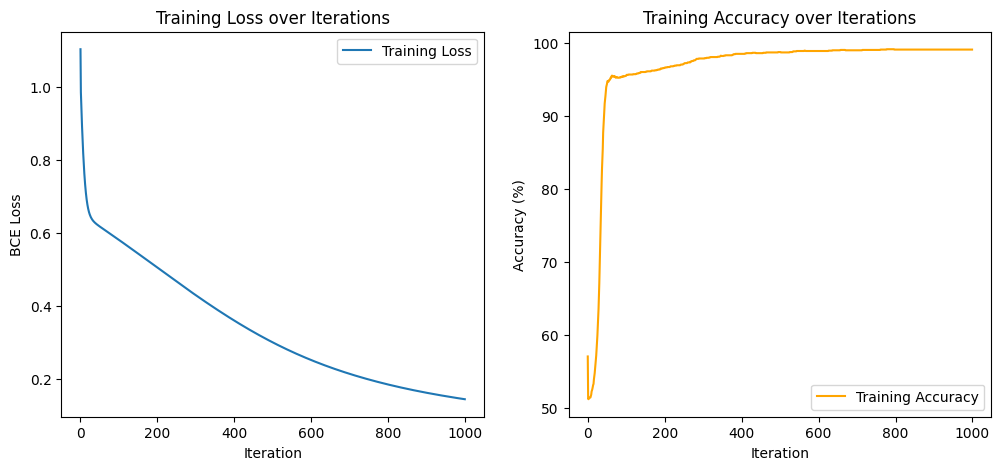

In [10]:
# Set hyperparameters
num_iters = 1000
learning_rate = 0.3
hidden_size = 64

# Initialize parameters
params = {
    'W1': np.random.normal(size=(hidden_size, features_train.shape[1])),  # (4, 2)
    'b1': np.random.normal(size=(1, hidden_size)),
    'W2': np.random.normal(size=(1, hidden_size)),
    'b2': np.random.normal()
}

# Reserve metrics storage
losses_train = []
accuracies_train = []

# Optimization iterations
for i in range(num_iters):
    # Forward pass
    preds_train, hid_feats_train = model_n11(features_train, params)
    # Compute loss and accuracy
    loss_train = bce_loss(preds_train, labels_train)
    acc_train = accuracy(preds_train, labels_train)
    losses_train.append(loss_train)
    accuracies_train.append(acc_train)
    # Log progress (every 50 iterations)   
    if i % 50 == 0 or i == num_iters - 1:
        print(f"Iter {i}: Train Loss {loss_train}, Train Acc {acc_train}")
    # Back-propagation
    grads = backward(features_train, hid_feats_train, preds_train, labels_train, params)
    # Gradient descent parameter update
    params['W1'] = params['W1'] - learning_rate * grads['dW1']
    params['b1'] = params['b1'] - learning_rate * grads['db1']
    params['W2'] = params['W2'] - learning_rate * grads['dW2']
    params['b2'] = params['b2'] - learning_rate * grads['db2']

# Plot training loss and accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(losses_train, label='Training Loss')
plt.xlabel('Iteration')
plt.ylabel('BCE Loss')
plt.title('Training Loss over Iterations')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(np.array(accuracies_train) * 100, label='Training Accuracy', color='orange')
plt.xlabel('Iteration')
plt.ylabel('Accuracy (%)')
plt.title('Training Accuracy over Iterations')
plt.legend()   

### To visualize decision boundary

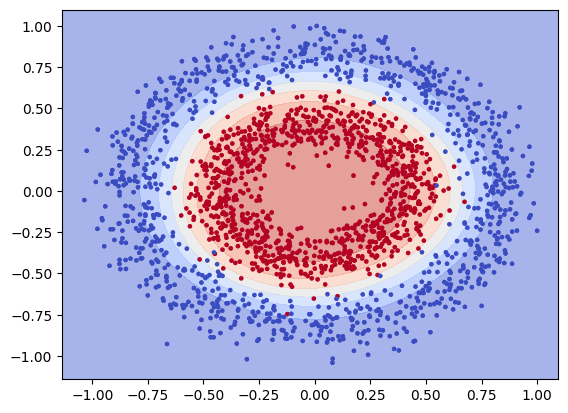

In [11]:
plt.scatter(features_train[:, 0], features_train[:, 1], s=5*np.ones(labels_train.size), c=labels_train, cmap='coolwarm')
plot_decision_boundary(features_train, labels_train, params)


## 8. Evaluate Model with a New Dataset
Let's generate a similar dataset using [make_circles](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_circles.html#sklearn.datasets.make_circles) as used in the beginning of this practice.
Make predictions and evaluate model with this newly generated dataset.


Text(0.5, 1.0, 'Classification over Validation Data')

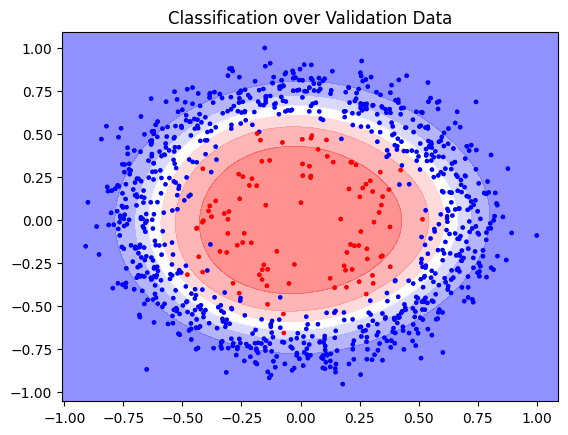

In [12]:
# Accuracy on training data
X_raw, y_raw = make_circles(n_samples=(900, 100), shuffle=True, noise=0.13, factor=0.5)
features_val = X_raw / X_raw.max(axis=0)  # Scale features to [-1, 1]
labels_val = y_raw.reshape(-1, 1)  # Reshape labels to be a column vector

# Visualize validation data
plt.scatter(
    features_val[:, 0], 
    features_val[:, 1], 
    s=5*np.ones(labels_val.size), 
    c=labels_val, 
    cmap='bwr'  # color map
)
# Visualize decision boundary on validation data
plot_decision_boundary(features_val, labels_val, params, color_map='bwr')
plt.title('Classification over Validation Data')

Besides accuracy, a handful of metrics are useful to evaluate how sensitive/precise/balance the model is. 
A confusion matrix is a handy tool to visualize these metrics.


Text(0.5, 1.0, 'Confusion Matrix - Validation Data')

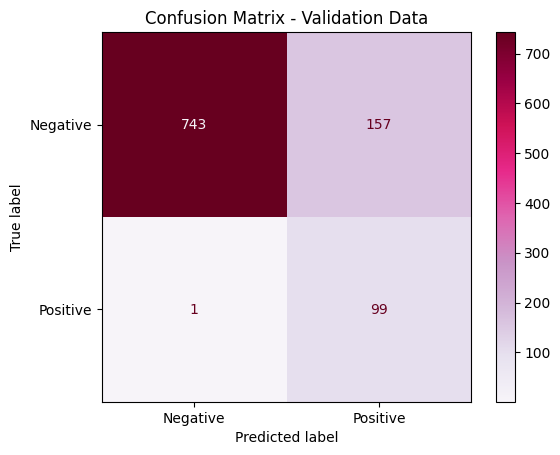

In [13]:
# Confusion Matrix for Test Data
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

preds_val = model_n11(features_val, params)[0]
cm_val = confusion_matrix(labels_val, (preds_val >= 0.5).astype(int))
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Negative', 'Positive'])
disp_val.plot(cmap='PuRd')
plt.title('Confusion Matrix - Validation Data')

### <font color=#582C83>(25%) Exercise 8: Classification Metrics</font>
According to your confusion matrix on the **test dataset**. Please calculate the following metrics and write your answers below.
> Hint: coding these metrics.

- `Accuracy`=?
- `Recall`=?
- `Precision`=?
- `F1 Score`=?




### <font color=#582C83>(25%) Exercise 9: Validation Analyses</font>
Assume the model is used by a factory's quality control department to detect defective (**positive**) products over 1000 samples (validation data).
Please answer the following questions **according to last exercise's statistcs**.

#### 1. Is the model good at picking out the defective products? Why?
> Answer

#### 2. What is the major problem the model could cause to the factory?
> Answer

# Congratulations! You have finished this assignment!